# Richard Mackwan
## Assignment 03, Problem 3

Building an image classifier for Fashion MNIST with PyTorch, following the section *Building an Image Classifier with PyTorch* of `reference/10_neural_nets_with_pytorch.ipynb`.

**From `scripts/step01_setup_device.py`** — Step 1: imports and device selection (cuda -> mps -> cpu).

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

n_epochs = 20

print(f"PyTorch {torch.__version__}, using device: {device}")


PyTorch 2.14.0+cu130, using device: cpu


**From `scripts/step02_load_data.py`** — Step 2: load Fashion MNIST with torchvision.transforms.v2, split 55,000/5,000 (seed 42) and build DataLoaders with batch size 32.

In [2]:
import torchvision
import torchvision.transforms.v2 as T

toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

train_and_valid_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=False, download=True, transform=toTensor)

torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [55_000, 5_000])

torch.manual_seed(42)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

# Each entry is an (image, target) tuple; images are [channels, rows, columns]
X_sample, y_sample = train_data[0]
print(f"train: {len(train_data)}, valid: {len(valid_data)}, "
      f"test: {len(test_data)}")
print(f"sample shape: {tuple(X_sample.shape)}, dtype: {X_sample.dtype}, "
      f"class: {train_and_valid_data.classes[y_sample]}")


train: 55000, valid: 5000, test: 10000
sample shape: (1, 28, 28), dtype: torch.float32, class: Ankle boot


**From `scripts/step03_training_helpers.py`** — Step 3: the evaluate_tm and train2 helpers (torchmetrics-based).

In [3]:
def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()  # reset the metric at the beginning
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)  # update it at each iteration
    return metric.compute()  # compute the final result at the end


def train2(model, optimizer, criterion, metric, train_loader, valid_loader,
           n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        for X_batch, y_batch in train_loader:
            model.train()
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history


**From `scripts/step04_build_model.py`** — Step 4: the ImageClassifier MLP (784 -> 300 -> 100 -> 10, ReLU) and the cross-entropy loss.

In [4]:
class ImageClassifier(nn.Module):
    def __init__(self, n_inputs, n_hidden1, n_hidden2, n_classes):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_inputs, n_hidden1),
            nn.ReLU(),
            nn.Linear(n_hidden1, n_hidden2),
            nn.ReLU(),
            nn.Linear(n_hidden2, n_classes)
        )

    def forward(self, X):
        return self.mlp(X)


torch.manual_seed(42)
model = ImageClassifier(n_inputs=1 * 28 * 28, n_hidden1=300, n_hidden2=100,
                        n_classes=10).to(device)
xentropy = nn.CrossEntropyLoss()
print(model)


ImageClassifier(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=300, bias=True)
    (2): ReLU()
    (3): Linear(in_features=300, out_features=100, bias=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=10, bias=True)
  )
)


**From `scripts/step05_train_model.py`** — Step 5: train for 20 epochs with SGD (lr=0.1) and torchmetrics Accuracy, then save the weights and the per-epoch history.

In [5]:
import json
import torchmetrics

optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
history = train2(model, optimizer, xentropy, accuracy, train_loader,
                 valid_loader, n_epochs)

torch.save(model.state_dict(), "fashion_mnist_mlp.pt")
with open("history.json", "w") as f:
    json.dump(history, f, indent=2)
print("Saved fashion_mnist_mlp.pt and history.json")


Epoch 1/20, train loss: 0.6060, train metric: 0.7814, valid metric: 0.8424


Epoch 2/20, train loss: 0.4061, train metric: 0.8496, valid metric: 0.8402


Epoch 3/20, train loss: 0.3630, train metric: 0.8661, valid metric: 0.8494


Epoch 4/20, train loss: 0.3355, train metric: 0.8768, valid metric: 0.8638


Epoch 5/20, train loss: 0.3154, train metric: 0.8829, valid metric: 0.8782


...

Epoch 16/20, train loss: 0.2078, train metric: 0.9196, valid metric: 0.8886


Epoch 17/20, train loss: 0.2033, train metric: 0.9233, valid metric: 0.8870


Epoch 18/20, train loss: 0.1991, train metric: 0.9230, valid metric: 0.8846


Epoch 19/20, train loss: 0.1916, train metric: 0.9266, valid metric: 0.8812


Epoch 20/20, train loss: 0.1876, train metric: 0.9286, valid metric: 0.8788
Saved fashion_mnist_mlp.pt and history.json


**From `scripts/step06_predict.py`** — Step 6: predict the first 3 validation images, then show the softmax probabilities and the top-4 class probabilities.

In [6]:
import torch.nn.functional as F

model.eval()
X_new, y_new = next(iter(valid_loader))
X_new = X_new[:3].to(device)
with torch.no_grad():
    y_pred_logits = model(X_new)
y_pred = y_pred_logits.argmax(dim=1)  # index of the largest logit
print("Predicted indices:", y_pred.tolist())
print("Predicted classes:",
      [train_and_valid_data.classes[index] for index in y_pred])
print("True indices:     ", y_new[:3].tolist())
print("True classes:     ",
      [train_and_valid_data.classes[index] for index in y_new[:3]])

y_proba = F.softmax(y_pred_logits, dim=1).cpu()
print("Class probabilities:\n", y_proba.round(decimals=3))

y_top4_values, y_top4_indices = torch.topk(y_pred_logits, k=4, dim=1)
y_top4_probas = F.softmax(y_top4_values, dim=1).cpu()
print("Top-4 probabilities:\n", y_top4_probas.round(decimals=3))
print("Top-4 class indices:\n", y_top4_indices.cpu())


Predicted indices: [7, 4, 2]
Predicted classes: ['Sneaker', 'Coat', 'Pullover']
True indices:      [7, 4, 2]
True classes:      ['Sneaker', 'Coat', 'Pullover']
Class probabilities:
 tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.8590, 0.0000,
         0.1410],
        [0.0000, 0.0000, 0.0070, 0.0000, 0.9930, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0040, 0.0000, 0.5920, 0.0000, 0.2120, 0.0000, 0.1910, 0.0000, 0.0010,
         0.0000]])
Top-4 probabilities:
 tensor([[0.8590, 0.1410, 0.0000, 0.0000],
        [0.9930, 0.0070, 0.0000, 0.0000],
        [0.5930, 0.2120, 0.1920, 0.0040]])
Top-4 class indices:
 tensor([[7, 9, 5, 1],
        [4, 2, 6, 8],
        [2, 4, 6, 0]])


**From `scripts/step07_count_parameters.py`** — Step 7: count the model's trainable parameters.

In [7]:
n_params = sum([param.numel() for param in model.parameters()])
print(f"Total parameters: {n_params:,}")  # 784*300+300 + 300*100+100 + 100*10+10


Total parameters: 266,610


**From `scripts/step08_plot_accuracy.py`** — Step 8: plot training and validation accuracy per epoch and save it to training_accuracy.png.

Saved training_accuracy.png


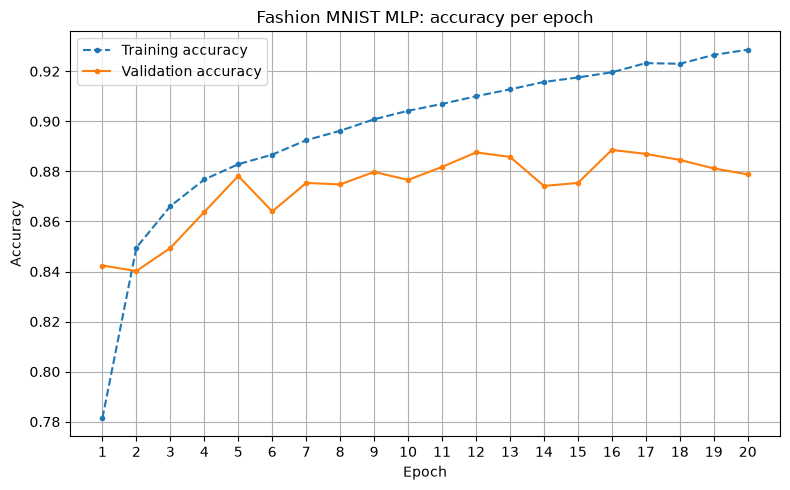

In [8]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_metrics"]) + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_metrics"], ".--", label="Training accuracy")
plt.plot(epochs, history["valid_metrics"], ".-", label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Fashion MNIST MLP: accuracy per epoch")
plt.xticks(list(epochs))
plt.grid()
plt.legend()
plt.tight_layout()
plt.savefig("training_accuracy.png", dpi=150)
print("Saved training_accuracy.png")
plt.show()
